In [81]:
import certifi
import os

os.environ['SSL_CERT_FILE'] = certifi.where()


import pickle
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import nltk
import re

nltk.download("stopwords")
from nltk.corpus import stopwords

stopwords_en = stopwords.words("english")

import matplotlib.pyplot as plt


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jared.mcbride/Documents/Code
[nltk_data]     Projects/venv/lib/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
stopwords_en

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [29]:
# Get my review data
dataCH = pickle.load(open("DataCh.pkl", "rb"))
dataOB = pickle.load(open("DataOb.pkl", "rb"))

In [30]:
# I included the ratings becuase I used them for the air compressor reviews project. I Don't need them here.
del dataOB["Rating"]
del dataCH["Rating"]

# I like what Keith did in his example
class sources:
    RIGHT = "Right"
    LEFT = "Left"

dataCH["Source"] = sources.RIGHT
dataOB["Source"] = sources.LEFT

data = pd.concat([dataCH, dataOB], ignore_index=True)
data

,Review,Source
0,Charlie Kirk was one of the most insightful yo...,Right
1,I wish I had read this 5 years ago when it fir...,Right
2,Charlie Kirk writes a very entertaining and in...,Right
3,"Well written, informative, and easy to follow....",Right
4,"I don't agree with all of it's content, but a ...",Right
...,...,...
195,I enjoyed this refreshing reminder of what a t...,Left
196,I bought this book to read to and with my son ...,Left
197,The book does not touch upon political episode...,Left
198,This is truly beautiful writing. In this horri...,Left


In [32]:
# update vectorizer to remove English stop words and rebuild features
# Notice I am using both unigrams and bigrams
vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words=stopwords_en)
X_vec = vectorizer.fit_transform(data["Review"])

In [33]:
X_vec.shape

(200, 15214)

15,214 is a lot of features!

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_vec, data["Source"], test_size=0.3, stratify=data["Source"], random_state=42)

# Verify class distribution
print("Training set class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting set class distribution:")
print(y_test.value_counts(normalize=True))

Training set class distribution:
Source
Left     0.5
Right    0.5
Name: proportion, dtype: float64

Testing set class distribution:
Source
Right    0.5
Left     0.5
Name: proportion, dtype: float64


In [35]:
mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

# Time: 7s (hidden layers = 128, 64; max_iter=500)

Confusion Matrix:
[[30  0]
 [14 16]]
Accuracy: 0.77


In [36]:
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train.toarray())
X_test_pca = pca.transform(X_test.toarray())

mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42)
mlp.fit(X_train_pca, y_train)
y_pred = mlp.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

# Time: 0.7s (hidden layers = 128, 64; max_iter=500; PCA n_components=50)

Confusion Matrix:
[[29  1]
 [ 2 28]]
Accuracy: 0.95


## Eliminate Polarizing Words

In [38]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=500, random_state=42)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[26  4]
 [ 3 27]]


In [55]:
abs_coef = abs(logreg.coef_[0])
ind = abs_coef.argsort()
ind.shape

(15214,)

In [ ]:
ind = ind[::-1]  # Reverse to get descending order
vectorizer.get_feature_names_out()[ind[:60]]  # Top 60 influential words


array(['charlie', 'trump', 'obama', 'read', 'love', 'kirk', 'brilliant',
       'president', 'books', 'book', 'son', 'charlie kirk', 'great',
       'great book', 'president trump', 'gift', 'read book', 'food',
       'food thought', 'mom loved', 'thought', 'great read', 'mom loves',
       'loves', 'loves books', 'promised', 'time', 'country', 'like',
       'land', 'promised land', 'learned lot', 'one', 'ok', 'ok learned',
       'lot book', 'excellent book', 'america', 'interesting', 'first',
       'good informational', 'informational', 'know must',
       'informational book', 'things know', 'really', 'things', 'going',
       'man', 'well written', 'written', 'donald', 'lot', 'loved',
       'loved book', 'family', 'writer', 'going review', 'son going',
       'forward'], dtype=object)

In [60]:
polarizing_words = "charlie kirk donald trump barak obama maga".split()
polarizing_words

['charlie', 'kirk', 'donald', 'trump', 'barak', 'obama', 'maga']

In [65]:
vectorizer_dp = CountVectorizer(ngram_range=(1, 2), stop_words=stopwords_en+polarizing_words)
X_vec_dp = vectorizer_dp.fit_transform(data["Review"])

X_vec_dp.shape

(200, 15018)

In [77]:
X_train_dp, X_test_dp, y_train, y_test = train_test_split(X_vec_dp, data["Source"], test_size=0.3, stratify=data["Source"], random_state=42)


In [78]:
mlp_dp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42)
mlp_dp.fit(X_train_dp, y_train)
y_pred = mlp_dp.predict(X_test_dp)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

# Time: 7s (hidden layers = 128, 64; max_iter=500)

Confusion Matrix:
[[29  1]
 [14 16]]
Accuracy: 0.75


In [79]:
pca_dp = PCA(n_components=.95)
X_train_pca_dp = pca_dp.fit_transform(X_train_dp.toarray())
X_test_pca_dp = pca_dp.transform(X_test_dp.toarray())  

mlp_dp_pca = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42)
mlp_dp_pca.fit(X_train_pca_dp, y_train)
y_pred = mlp_dp_pca.predict(X_test_pca_dp)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

Confusion Matrix:
[[18 12]
 [ 4 26]]
Accuracy: 0.73


## Linear SVM (More effective and more interpretable!)

In [80]:
from sklearn.svm import SVC

svc = SVC(random_state=42)
svc.fit(X_train_dp, y_train)
y_pred = svc.predict(X_test_dp)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")  

Confusion Matrix:
[[24  6]
 [ 0 30]]
Accuracy: 0.90


Wow!

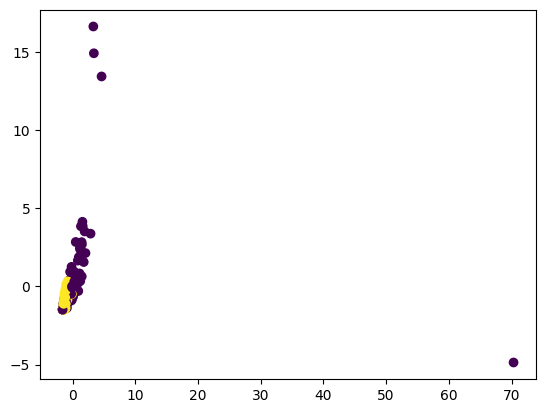

In [ ]:
plt.scatter(X_train_pca_dp[:,0], X_train_pca_dp[:,1], c = y_train.map({sources.LEFT:0, sources.RIGHT:1}))

In [90]:
X_train_pca_dp.shape

(140, 81)

In [83]:
X_train_pca_dp.argmax()

0

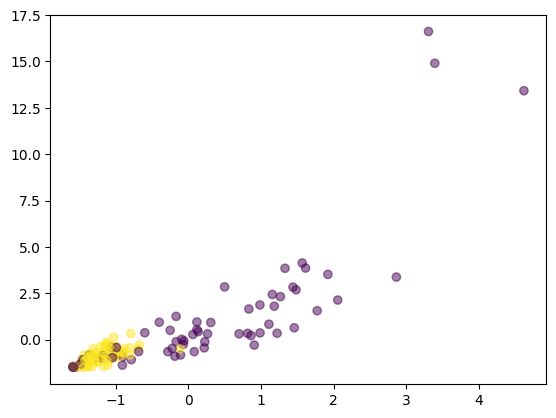

In [131]:
plt.scatter(X_train_pca_dp[1:,0], X_train_pca_dp[1:,1], c = y_train[1:].map({sources.LEFT:0, sources.RIGHT:1}),alpha=0.5)



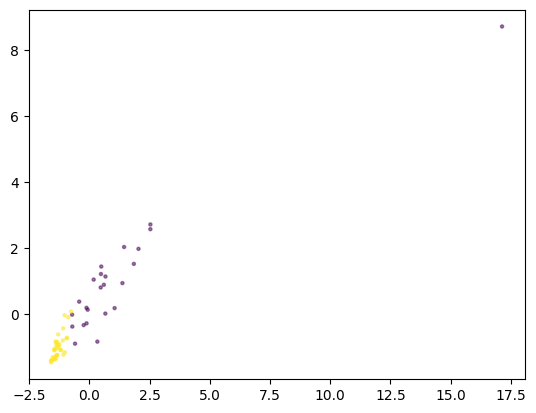

In [134]:
# plt.scatter(X_test_pca_dp[1:,0], X_test_pca_dp[1:,1], c = y_test[1:].map({sources.LEFT:0, sources.RIGHT:1}),alpha=0.5)
plt.scatter(X_test_pca_dp[1:,0], X_test_pca_dp[1:,1], marker = "o", s=5, c = np.where(y_pred[1:] == sources.LEFT, 0, 1).tolist(),alpha=0.5)




In [89]:
pca_dp.components_.shape

(81, 15018)

In [117]:
## Round a bit and make sparse
C = np.round(pca_dp.components_, 5)

C1 = C[0,:].argsort()
C1df = pd.DataFrame({"Loading C1" : C[0,C1[::-1]], "FeatureC1" : np.array(vectorizer_dp.get_feature_names_out())[C1[::-1]]})
C1df.head(20)

C2 = C[1,:].argsort()
C2df = pd.DataFrame({"Loading C2" : C[1,C2[::-1]], "FeatureC2" : np.array(vectorizer_dp.get_feature_names_out())[C2[::-1]]}) 
Cdf = pd.concat([C1df, C2df], axis=1)
Cdf.head(20)


,Loading C1,FeatureC1,Loading C2,FeatureC2
0,0.17290,time,0.37810,book
1,0.15879,president,0.19430,read
2,0.12732,presidency,0.15978,also
3,0.12379,book,0.10327,us
4,0.11128,made,0.10134,personal
5,0.11094,would,0.09512,world
6,0.11084,crisis,0.09104,first
7,0.09560,although,0.08740,words
8,0.08688,like,0.08349,thoughtful
9,0.08447,much,0.08153,time
